### **Chapter 9.9: Two Summary Figures**

This notebook produces two self-contained figures that condense the chapter for a talk or paper. Everything that one might want to change is collected in the hyper-parameter cell below; the figures are written to `figures/`.

1. **Flat terrain, no disturbance** - DeePC with an offline trajectory that is *too short*, *just long enough*, and *longer than necessary*, against the MPC with the exact model. Left: time-RMS deviation of the DeePC position trajectory from the MPC trajectory as a function of the data length $T$, with the data-length bound marked. Right: the position trajectories for the three highlighted data lengths.
2. **Bumpy terrain, data length** - the same experiment on the nonlinear plant, with data recorded *on that plant* and regularized DeePC against the nonlinear MPC with the true model. The theoretical bound is no longer where things become good: several times more data are needed before the deviation settles, and it settles at a floor set by the plant mismatch, not at zero.
3. **Bumpy terrain, regularization** (DeePC data from the flat plant, as in Chapter 9.5) - DeePC for a grid of regularization weights $(\lambda_g, \lambda_y)$ against the nonlinear MPC with the true model and, optionally, the MPC with the flat model. Left: RMS deviation from the true-model MPC as a function of $\lambda_g$ with one curve per $\lambda_y$. Right: trajectories for selected settings.

The deviation measure is the root-mean-square position deviation over the whole run,
$$
d = \Bigl(\tfrac{1}{K+1}\sum_{k=0}^{K} \bigl(p_k^{\mathrm{DeePC}} - p_k^{\mathrm{MPC}}\bigr)^2\Bigr)^{1/2},
$$
a time-averaged quantity in metres that is zero if and only if the two closed loops coincide (a maximum deviation would be dominated by single samples; a cost difference could be zero for different trajectories).

In [1]:
import sys
import os
import io
import contextlib
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from utils.env import *
from ex9_DeePC.deepc_utils import *

OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
plt.rcParams.update({
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 11, "legend.fontsize": 9,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 1.8,
    "axes.prop_cycle": plt.cycler(color=OKABE_ITO),
})
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight")

#### **Hyper-parameters**

In [2]:
# ---- shared -------------------------------------------------------------------
freq = 20
dt = 1.0 / freq
N = 20
T_ini = 4
t_terminal = 6.0
initial_state = np.array([-0.5, 0.0])
target_state = np.array([0.6, 0.0])
input_lbs, input_ubs = -1.0, 1.0
Q_y = np.array([[1.0]]); R = np.array([[0.1]]); Qf_y = Q_y          # DeePC / flat-model MPC (output y = p)
Q_x = np.diag([1.0, 0.0]); Qf_x = Q_x                                # the same cost on the state, for the nonlinear MPC
EXCITATION_AMPLITUDE = 0.8
DATA_SEED = 1

# ---- figure 1: flat terrain, data length ------------------------------------------
T_SWEEP = list(range(40, 67))                                        # data lengths for the left panel; any list works
T_HIGHLIGHT = {"below bound": 48, "at bound": 51, "above bound": 60} # data lengths shown on the right panel
LAMBDA_G_FLAT = 1e-10                                                # (numerical) regularization on clean data

# ---- figure 2: bumpy terrain, data length ---------------------------------------
BRIDGE_BUMP_AMPLITUDE = 0.0025                                       # k of the plant that also generates the data
BRIDGE_T_SWEEP = [51, 55, 60, 70, 80, 100, 120, 150, 200, 300, 400]   # bound is 51 for T_ini = 4
BRIDGE_T_HIGHLIGHT = {"at bound": 51, "above bound": 60, "far above bound": 150}
BRIDGE_N_SEEDS = 10                                                  # independent data records per T (median and 10-90 % band)
BRIDGE_T_INI = 4                                                     # longer history than the lag: averages the "nonlinearity noise" (Chapter 9.6)
BRIDGE_LAMBDA_G_REL = 0.1                                            # lambda_g = value * (energy of the deviation data)
BRIDGE_LAMBDA_Y = 1e4
BRIDGE_EXCITATION_AMPLITUDE = 0.6                                    # closed-loop excitation around the target

# ---- figure 3: bumpy terrain, regularization -------------------------------------
BUMP_AMPLITUDE = 0.005                                               # k in h(p) = k cos(18 p); keep <= 0.0057 (input bound)
T_DATA_BUMPY = 400                                                   # flat-terrain data used by DeePC
LAMBDA_G_GRID = [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]
LAMBDA_Y_GRID = [1e3, 1e4, 1e5]                                      # one curve per value on the left panel
TRAJECTORY_SETTINGS = [(1e-2, 1e5), (1.0, 1e4), (1e1, 1e3)]         # (lambda_g, lambda_y) shown on the right panel
SHOW_TRUE_MODEL_MPC = True                                           # nonlinear MPC with the true (bumpy) model
SHOW_FLAT_MODEL_MPC = True                                           # MPC with the flat model
P_PLOT_LIMITS = (-0.7, 1.6)                                          # y-range of the trajectory panel (runaways are clipped and marked)

In [3]:
env_flat = Env(1, initial_state, target_state, input_lbs=input_lbs, input_ubs=input_ubs)
dyn_flat = Dynamics(env_flat)
a_true, b_true = true_arx_double_integrator(dt)
n_states, m_inputs = 2, 1
L = T_ini + N
T_BOUND = (m_inputs + 1) * (L + n_states) - 1

def run_closed_loop(controller, plant, env_run, t_end=t_terminal):
    x = env_run.init_state.copy()
    states, inputs, failures = [x.copy()], [], 0
    for k in range(int(freq * t_end)):
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                u = controller.compute_action(x, k)
            u = u[0] if isinstance(u, tuple) else u
        except RuntimeError:
            failures += 1
            u = np.zeros(1)
            if isinstance(controller, DeePCController):
                controller.initialize_history(x, mode='equilibrium')
        u = np.clip(np.asarray(u, dtype=float).reshape(-1), input_lbs, input_ubs)
        x = plant.one_step_forward(x, u, dt)
        states.append(x.copy()); inputs.append(u.copy())
    return np.asarray(states), np.asarray(inputs), failures

def rms_deviation(X, X_ref):
    return float(np.sqrt(np.mean((X[:, 0] - X_ref[:, 0])**2)))

t_x = np.arange(int(freq * t_terminal) + 1) * dt

### **Figure 1: Flat terrain - how much data does DeePC need?**

The sufficient bound for persistency of excitation is $T \ge (m+1)(T_{\mathrm{ini}}+N+n)-1$. Below it, the controller's own check rejects the data; for this figure the check is switched off (`enforce_pe_check=False`) so that we can see what happens: the history constraints become infeasible at every step and the fallback input $u=0$ keeps the car where it is.

In [4]:
u_long, y_long = collect_deepc_data(env_flat, dyn_flat, freq=freq, n_samples=max(T_SWEEP), excitation_amplitude=EXCITATION_AMPLITUDE,
                                    initial_state=target_state, seed=DATA_SEED, output_indices=[0])
X_mpc_flat, U_mpc_flat, _ = run_closed_loop(ARXPredictiveController(env_flat, dyn_flat, a_true, b_true, Q_y, R, Qf_y, freq, N), dyn_flat, env_flat)

def deepc_flat(T):
    return DeePCController(env_flat, dyn_flat, u_long[:T], y_long[:T + 1], Q_y, R, Qf_y, freq, N, T_ini=T_ini,
                           lambda_g=LAMBDA_G_FLAT, output_indices=[0], history_initialization='equilibrium',
                           enforce_pe_check=False, verbose=False)

def evaluate_flat(T):
    c = deepc_flat(T)
    X, U, fails = run_closed_loop(c, dyn_flat, env_flat)
    return (T, c.pe_rank, c.pe_required_rank, rms_deviation(X, X_mpc_flat), fails), X

sweep = [evaluate_flat(T)[0] for T in T_SWEEP]
highlight = {label: evaluate_flat(T) for label, T in T_HIGHLIGHT.items()}   # evaluated separately: need not be in T_SWEEP

print(f"sufficient bound: T >= {T_BOUND};  Hankel columns = T - L + 1, rank needed = m L + n = {m_inputs * L + n_states}")
print(f"{'T':>5} {'rank H_L+n(u)':>14} {'columns':>8} {'RMS dev. (m)':>13} {'infeasible steps':>17}")
for T, rk, rq, d, f in sweep:
    print(f"{T:5d} {rk:8d}/{rq:<5d} {T - L + 1:8d} {d:13.2e} {f:17d}")

sufficient bound: T >= 51;  Hankel columns = T - L + 1, rank needed = m L + n = 26
    T  rank H_L+n(u)  columns  RMS dev. (m)  infeasible steps
   40       15/26          17      9.99e-01               120
   41       16/26          18      9.99e-01               120
   42       17/26          19      9.99e-01               120
   43       18/26          20      9.99e-01               120
   44       19/26          21      9.99e-01               120
   45       20/26          22      9.99e-01               120
   46       21/26          23      9.99e-01               120
   47       22/26          24      9.99e-01               120
   48       23/26          25      9.99e-01               120
   49       24/26          26      1.99e-07                 0
   50       25/26          27      1.24e-08                 0
   51       26/26          28      6.53e-09                 0
   52       26/26          29      4.88e-09                 0
   53       26/26          30      3.81e-09      

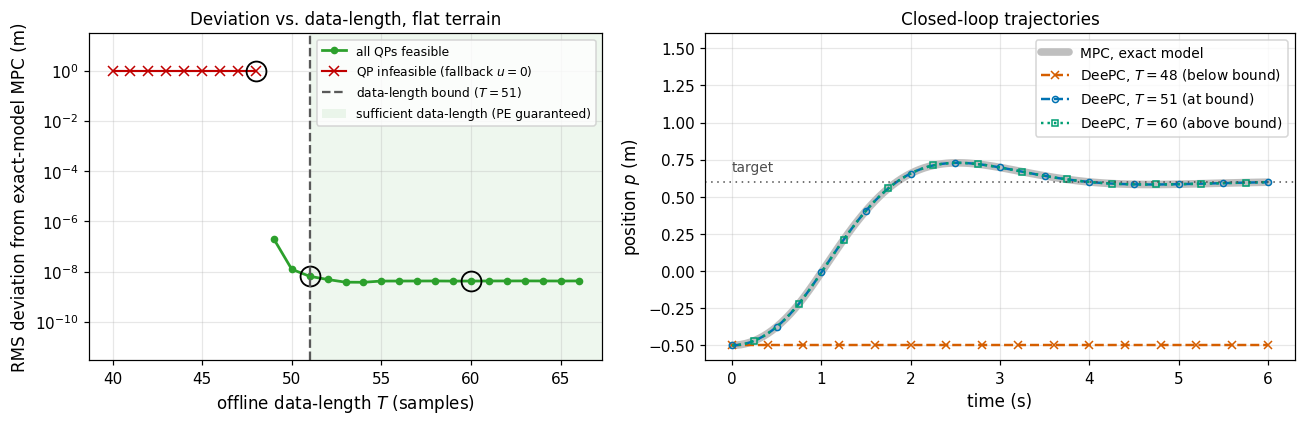

In [5]:
Ts = np.array([s[0] for s in sweep]); devs = np.array([s[3] for s in sweep]); fails = np.array([s[4] for s in sweep])
C_LEFT, C_INFEAS, C_BOUND = "#2CA02C", "#C00000", "0.35"  # feasible: green, infeasible: red, bound: grey

fig, ax = plt.subplots(1, 2, figsize=(12, 4.0), width_ratios=[1, 1.15])
ok = fails == 0
ax[0].semilogy(Ts[ok], np.maximum(devs[ok], 1e-12), marker="o", ms=4, color=C_LEFT, label="all QPs feasible")
ax[0].semilogy(Ts[~ok], devs[~ok], marker="x", ms=7, ls="-", lw=1.4, color=C_INFEAS, label="QP infeasible (fallback $u=0$)")
for label, (row, _) in highlight.items():          # circled: the data lengths whose trajectories are shown on the right
    ax[0].plot(row[0], max(row[3], 1e-12), marker="o", ms=13, mfc="none", mec="k", mew=1.2, ls="none")
ax[0].axvline(T_BOUND, color=C_BOUND, ls="--", lw=1.5, label=f"data-length bound ($T={T_BOUND}$)")
ax[0].set_ylim(3e-12, 30)
x_left, x_right = ax[0].get_xlim()
# the region where the sufficient data-length condition holds, shaded lightly in the feasible color
ax[0].axvspan(T_BOUND, x_right, color=C_LEFT, alpha=0.08, lw=0, zorder=0,
              label="sufficient data-length (PE guaranteed)")
ax[0].set_xlim(x_left, x_right)
ax[0].set_xlabel("offline data-length $T$ (samples)"); ax[0].set_ylabel("RMS deviation from exact-model MPC (m)")
ax[0].set_title("Deviation vs. data-length, flat terrain"); ax[0].legend(loc="best", fontsize=8)

ax[1].plot(t_x, X_mpc_flat[:, 0], color="0.75", lw=5, solid_capstyle="round", label="MPC, exact model")
styles = [dict(color=OKABE_ITO[3], ls="--", marker="x", markevery=8, ms=5),
          dict(color=OKABE_ITO[0], ls="--", marker="o", markevery=(0, 10), ms=4, mfc="none"),
          dict(color=OKABE_ITO[2], ls=":", marker="s", markevery=(5, 10), ms=4, mfc="none")]
for j, (label, T) in enumerate(T_HIGHLIGHT.items()):
    ax[1].plot(t_x, highlight[label][1][:, 0], lw=1.6, label=f"DeePC, $T={T}$ ({label})", **styles[j % len(styles)])
ax[1].axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], target_state[0] + 0.05, "target", ha="left", va="bottom", fontsize=9, color="0.3")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$ (m)"); ax[1].set_title("Closed-loop trajectories"); ax[1].legend(loc="best")
ax[1].set_ylim(-0.6, 1.6)
plt.tight_layout()
savefig(fig, "9.9_fig1_flat_data_length")
plt.show()

### **Figure 2: Bumpy terrain - how much data does DeePC need in practice?**

Same experiment, nonlinear plant $h(p) = k\cos(18p)$. The data are recorded on this plant in closed loop around the target (`collect_deepc_data_closed_loop`, Chapter 9.6), so the Hankel matrix is full rank like a noisy one and the regularized formulation is used ($\lambda_y$ fixed, $\lambda_g$ scaled with the data energy). The reference is the nonlinear MPC with the true model. Because a single record of length $T$ is one random realization, every $T$ is repeated for several data seeds and the median with the 10-90 % band is shown.

In [6]:
env_br = Env(3, initial_state, target_state, param=BRIDGE_BUMP_AMPLITUDE, state_lbs=np.array([-2.0, -4.0]), state_ubs=np.array([2.0, 4.0]),
             input_lbs=input_lbs, input_ubs=input_ubs)
dyn_br = Dynamics(env_br)
A_d, B_d = dyn_flat.get_linearized_AB_discrete(target_state, np.zeros(1), dt)
P_lqr = scipy.linalg.solve_discrete_are(A_d, B_d, Q_x, R)
K_lqr = np.linalg.solve(R + B_d.T @ P_lqr @ B_d, B_d.T @ P_lqr @ A_d)
u_eq_br = np.atleast_1d(dyn_br.get_equilibrium_input(target_state))
X_true_br, _, _ = run_closed_loop(NonlinearMPCOracle(env_br, dyn_br, Q_x, R, Qf_x, freq, N), dyn_br, env_br)
T_BOUND_BR = (m_inputs + 1) * (BRIDGE_T_INI + N + n_states) - 1

def deepc_bridge(T, seed):
    u_d, y_d = collect_deepc_data_closed_loop(env_br, dyn_br, freq=freq, n_samples=T, feedback_gain=K_lqr,
                                              excitation_amplitude=BRIDGE_EXCITATION_AMPLITUDE, seed=100 + seed, output_indices=[0])
    energy = float(np.sum((u_d - u_eq_br)**2) + np.sum((y_d - target_state[0])**2))
    return DeePCController(env_br, dyn_br, u_d, y_d, Q_y, R, Qf_y, freq, N, T_ini=BRIDGE_T_INI, lambda_g=BRIDGE_LAMBDA_G_REL * energy,
                           lambda_y=BRIDGE_LAMBDA_Y, output_indices=[0], history_initialization='equilibrium', enforce_pe_check=False, verbose=False)

dev_br = np.zeros((len(BRIDGE_T_SWEEP), BRIDGE_N_SEEDS))
for i, T in enumerate(BRIDGE_T_SWEEP):
    for sd in range(BRIDGE_N_SEEDS):
        X, _, _ = run_closed_loop(deepc_bridge(T, sd), dyn_br, env_br)
        dev_br[i, sd] = rms_deviation(X, X_true_br)
traj_br = {label: run_closed_loop(deepc_bridge(T, 0), dyn_br, env_br)[0] for label, T in BRIDGE_T_HIGHLIGHT.items()}

print(f"k = {BRIDGE_BUMP_AMPLITUDE}, T_ini = {BRIDGE_T_INI}: data-length bound T = {T_BOUND_BR}; true-model MPC final p {X_true_br[-1, 0]:.3f}")
print(f"{'T':>5} {'median dev (m)':>15} {'10 %':>8} {'90 %':>8}")
for i, T in enumerate(BRIDGE_T_SWEEP):
    print(f"{T:5d} {np.median(dev_br[i]):15.3f} {np.percentile(dev_br[i], 10):8.3f} {np.percentile(dev_br[i], 90):8.3f}")

k = 0.0025, T_ini = 4: data-length bound T = 51; true-model MPC final p 0.600
    T  median dev (m)     10 %     90 %
   51           0.755    0.196    3.663
   55           1.061    0.179    5.582
   60           0.269    0.175    5.094
   70           0.171    0.087    1.778
   80           0.236    0.120    1.676
  100           0.328    0.176    1.445
  120           0.269    0.135    0.520
  150           0.220    0.181    0.302
  200           0.196    0.171    0.248
  300           0.182    0.160    0.204
  400           0.187    0.165    0.203


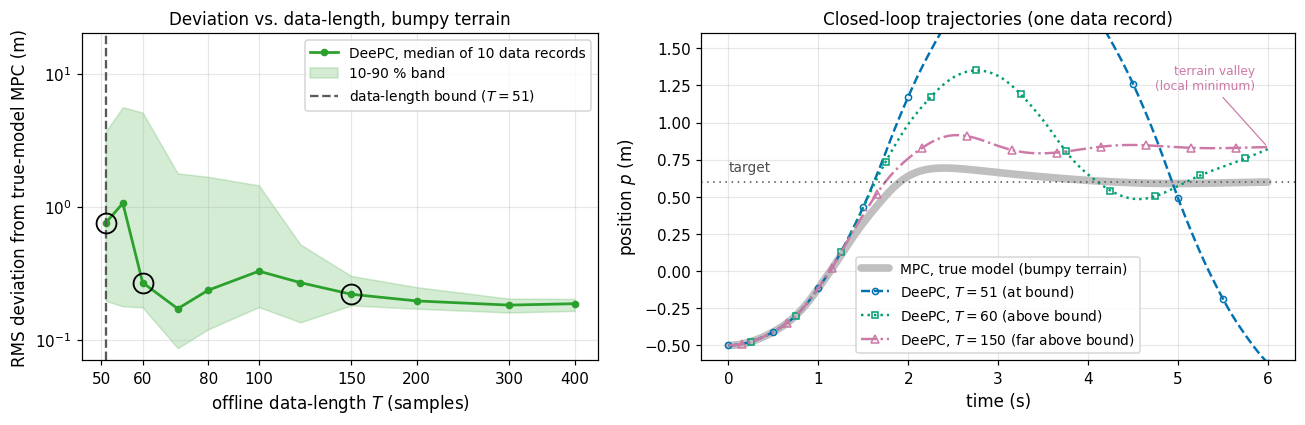

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.0), width_ratios=[1, 1.15])
Tb = np.array(BRIDGE_T_SWEEP)
ax[0].plot(Tb, np.median(dev_br, axis=1), marker="o", ms=4, color=C_LEFT, label=f"DeePC, median of {BRIDGE_N_SEEDS} data records")
ax[0].fill_between(Tb, np.percentile(dev_br, 10, axis=1), np.percentile(dev_br, 90, axis=1), color=C_LEFT, alpha=0.2, label="10-90 % band")
ax[0].axvline(T_BOUND_BR, color=C_BOUND, ls="--", lw=1.5, label=f"data-length bound ($T={T_BOUND_BR}$)")
for label, T in BRIDGE_T_HIGHLIGHT.items():      # circled: the data lengths whose trajectories are shown on the right
    if T in BRIDGE_T_SWEEP:
        ax[0].plot(T, np.median(dev_br[BRIDGE_T_SWEEP.index(T)]), marker="o", ms=13, mfc="none", mec="k", mew=1.2, ls="none")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
x_ticks = [t for t in [50, 60, 80, 100, 150, 200, 300, 400, 600, 800, 1000] if Tb.min() * 0.95 <= t <= Tb.max() * 1.05]
ax[0].set_xticks(x_ticks); ax[0].set_xticklabels([str(t) for t in x_ticks]); ax[0].minorticks_off()
ax[0].set_ylim(top=2e1)
ax[0].set_xlabel("offline data-length $T$ (samples)"); ax[0].set_ylabel("RMS deviation from true-model MPC (m)")
ax[0].set_title("Deviation vs. data-length, bumpy terrain"); ax[0].legend(loc="upper right")

ax[1].plot(t_x, X_true_br[:, 0], color="0.75", lw=5, solid_capstyle="round", label="MPC, true model (bumpy terrain)")
# colors consistent with figure 1: blue = at bound, green = above bound; purple for the third length
bridge_styles = [dict(color=OKABE_ITO[0], ls="--", marker="o", markevery=(0, 10), ms=4, mfc="none"),
                 dict(color=OKABE_ITO[2], ls=":", marker="s", markevery=(5, 10), ms=4, mfc="none"),
                 dict(color=OKABE_ITO[4], ls="-.", marker="^", markevery=(3, 10), ms=5, mfc="none")]
for j, (label, T) in enumerate(BRIDGE_T_HIGHLIGHT.items()):
    ax[1].plot(t_x, traj_br[label][:, 0], lw=1.6, label=f"DeePC, $T={T}$ ({label})", **bridge_styles[j % len(bridge_styles)])
ax[1].axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], target_state[0] + 0.05, "target", ha="left", va="bottom", fontsize=9, color="0.3")
# the well-fed controller settles in the terrain valley after the target (a local minimum), not at the target
X_far = traj_br[list(BRIDGE_T_HIGHLIGHT)[-1]]
ax[1].annotate("terrain valley\n(local minimum)", (t_x[-1], X_far[-1, 0]), textcoords="offset points", xytext=(-8, 38), ha="right", fontsize=8,
               color=OKABE_ITO[4], arrowprops=dict(arrowstyle="-", color=OKABE_ITO[4], lw=0.8))
ax[1].set_ylim(*P_PLOT_LIMITS)
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$ (m)"); ax[1].set_title("Closed-loop trajectories (one data record)"); ax[1].legend(loc="best")
ax[1].set_ylim(-0.6, 1.6)
plt.tight_layout()
savefig(fig, "9.9_fig2_bumpy_data_length")
plt.show()

### **Figure 3: Bumpy terrain - what regularization buys and costs**

The plant is $h(p) = k\cos(18p)$; DeePC uses flat-terrain data (Chapter 9.5) and the regularized formulation. Reference controllers: the nonlinear MPC with the true bumpy model (`NonlinearMPCOracle`, CasADi/ipopt, same $Q, R, Q_f, N$ written on the state) and the MPC with the flat model (`ARXPredictiveController`). The RMS deviation is measured from the true-model MPC.

In [8]:
env_bumpy = Env(3, initial_state, target_state, param=BUMP_AMPLITUDE, state_lbs=np.array([-2.0, -4.0]), state_ubs=np.array([2.0, 4.0]),
                input_lbs=input_lbs, input_ubs=input_ubs)
dyn_bumpy = Dynamics(env_bumpy)
theta_max = np.arctan(18 * BUMP_AMPLITUDE)
print(f"k = {BUMP_AMPLITUDE}: peak terrain force {9.81 * np.sin(theta_max) * np.cos(theta_max):.3f} (input bound {input_ubs})")

u_d, y_d = collect_deepc_data(env_flat, dyn_flat, freq=freq, n_samples=T_DATA_BUMPY, excitation_amplitude=EXCITATION_AMPLITUDE,
                              initial_state=target_state, seed=DATA_SEED, output_indices=[0])

X_true, _, f_true = run_closed_loop(NonlinearMPCOracle(env_bumpy, dyn_bumpy, Q_x, R, Qf_x, freq, N), dyn_bumpy, env_bumpy)
X_flatm, _, _ = run_closed_loop(ARXPredictiveController(env_bumpy, dyn_bumpy, a_true, b_true, Q_y, R, Qf_y, freq, N), dyn_bumpy, env_bumpy)
print(f"true-model MPC: final p {X_true[-1, 0]:.3f} (solver failures {f_true});  flat-model MPC: final p {X_flatm[-1, 0]:.3f}, RMS deviation {rms_deviation(X_flatm, X_true):.3f} m")

def deepc_bumpy(lambda_g, lambda_y):
    return DeePCController(env_bumpy, dyn_bumpy, u_d, y_d, Q_y, R, Qf_y, freq, N, T_ini=T_ini, lambda_g=lambda_g, lambda_y=lambda_y,
                           output_indices=[0], history_initialization='equilibrium', verbose=False)

dev_grid = np.zeros((len(LAMBDA_Y_GRID), len(LAMBDA_G_GRID)))
final_grid = np.zeros_like(dev_grid)
for iy, ly in enumerate(LAMBDA_Y_GRID):
    for ig, lg in enumerate(LAMBDA_G_GRID):
        X, U, fails = run_closed_loop(deepc_bumpy(lg, ly), dyn_bumpy, env_bumpy)
        dev_grid[iy, ig] = rms_deviation(X, X_true); final_grid[iy, ig] = X[-1, 0]
traj_bumpy = {(lg, ly): run_closed_loop(deepc_bumpy(lg, ly), dyn_bumpy, env_bumpy)[0] for lg, ly in TRAJECTORY_SETTINGS}

print(f"\nRMS deviation from true-model MPC (m)  [final position in brackets]")
header = "lambda_y / lambda_g"
print(f"{header:>20} " + " ".join(f"{lg:>14.0e}" for lg in LAMBDA_G_GRID))
for iy, ly in enumerate(LAMBDA_Y_GRID):
    print(f"{ly:>20.0e} " + " ".join(f"{dev_grid[iy, ig]:6.3f} [{final_grid[iy, ig]:5.2f}]" for ig in range(len(LAMBDA_G_GRID))))

k = 0.005: peak terrain force 0.876 (input bound 1.0)
true-model MPC: final p 0.600 (solver failures 0);  flat-model MPC: final p 0.886, RMS deviation 0.221 m

RMS deviation from true-model MPC (m)  [final position in brackets]
 lambda_y / lambda_g          1e-03          1e-02          1e-01          1e+00          1e+01          1e+02          1e+03
               1e+03  4.528 [11.76]  4.511 [11.72]  4.277 [11.19]  2.623 [ 7.28]  2.275 [ 6.38]  4.606 [11.88]  4.961 [12.57]
               1e+04  2.651 [ 7.41]  2.635 [ 7.37]  2.404 [ 6.80]  0.685 [ 1.13]  0.910 [ 1.90]  2.980 [ 8.13]  4.351 [11.23]
               1e+05  0.200 [ 0.86]  0.200 [ 0.86]  0.201 [ 0.86]  0.211 [ 0.86]  0.445 [ 1.22]  0.941 [ 1.92]  2.960 [ 8.09]


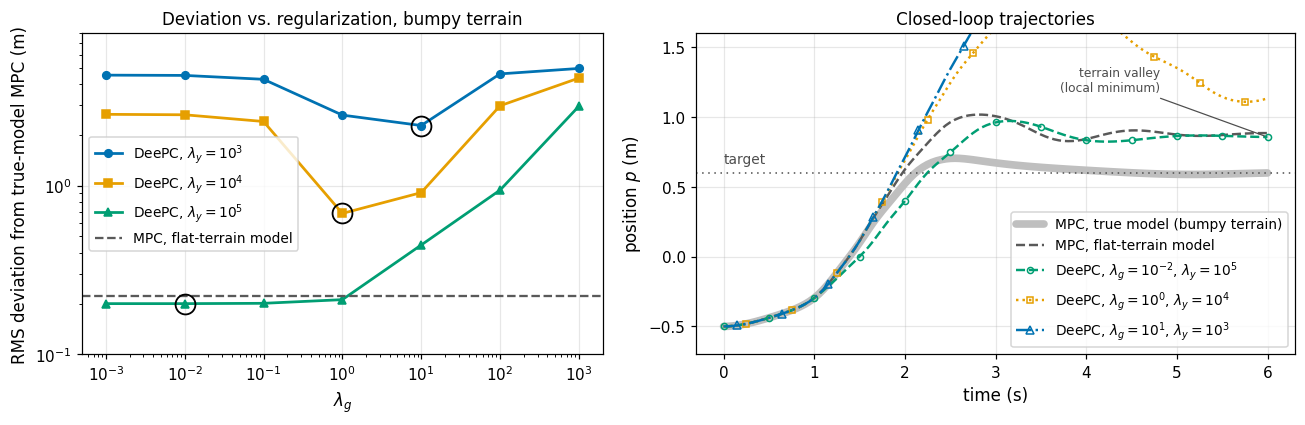

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.0), width_ratios=[1, 1.15])
markers = ["o", "s", "^", "D", "v"]
for iy, ly in enumerate(LAMBDA_Y_GRID):
    ax[0].loglog(LAMBDA_G_GRID, dev_grid[iy], marker=markers[iy % len(markers)], ms=5, color=OKABE_ITO[iy], label=f"DeePC, $\\lambda_y = 10^{{{int(np.log10(ly))}}}$")
if SHOW_FLAT_MODEL_MPC:
    ax[0].axhline(rms_deviation(X_flatm, X_true), color="0.35", ls="--", lw=1.5, label="MPC, flat-terrain model")
for lg, ly in TRAJECTORY_SETTINGS:
    iy, ig = LAMBDA_Y_GRID.index(ly), LAMBDA_G_GRID.index(lg)
    ax[0].plot(lg, dev_grid[iy, ig], marker="o", ms=13, mfc="none", mec="k", mew=1.2, ls="none")
ax[0].set_xlabel(r"$\lambda_g$"); ax[0].set_ylabel("RMS deviation from true-model MPC (m)")
ax[0].set_title("Deviation vs. regularization, bumpy terrain"); ax[0].legend(loc="best")
ax[0].set_ylim(0.1, 8)

if SHOW_TRUE_MODEL_MPC:
    ax[1].plot(t_x, X_true[:, 0], color="0.75", lw=5, solid_capstyle="round", label="MPC, true model (bumpy terrain)")
if SHOW_FLAT_MODEL_MPC:
    ax[1].plot(t_x, X_flatm[:, 0], color="0.35", lw=1.6, ls="--", label="MPC, flat-terrain model")
# same line styles / colors as the highlighted trajectories in figures 1 and 2
# colors keyed to lambda_y, matching the curves of the left panel
line_styles = [dict(ls="--", marker="o", markevery=(0, 10), ms=4, mfc="none"),
               dict(ls=":", marker="s", markevery=(5, 10), ms=4, mfc="none"),
               dict(ls="-.", marker="^", markevery=(3, 10), ms=5, mfc="none")]
def lam_label(lg, ly):
    return f"DeePC, $\\lambda_g=10^{{{int(np.log10(lg))}}}$, $\\lambda_y=10^{{{int(np.log10(ly))}}}$"
for j, (lg, ly) in enumerate(TRAJECTORY_SETTINGS):
    X = traj_bumpy[(lg, ly)]
    label = lam_label(lg, ly) # + (" (runaway)" if X[:, 0].max() > P_PLOT_LIMITS[1] else "")
    ax[1].plot(t_x, X[:, 0], lw=1.6, label=label, color=OKABE_ITO[LAMBDA_Y_GRID.index(ly)], **line_styles[j % len(line_styles)])
ax[1].axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=1)
ax[1].text(t_x[0], target_state[0] + 0.05, "target", ha="left", va="bottom", fontsize=9, color="0.3")
# the settled DeePC trajectory ends in the terrain valley after the target (a local minimum)
X_settled = min((traj_bumpy[s] for s in TRAJECTORY_SETTINGS), key=lambda X: X[:, 0].max())
ax[1].annotate("terrain valley\n(local minimum)", (t_x[-1], X_settled[-1, 0]), textcoords="offset points", xytext=(-70, 30), ha="right",
               fontsize=8, color="0.3", arrowprops=dict(arrowstyle="-", color="0.3", lw=0.8))
ax[1].set_ylim(*P_PLOT_LIMITS)
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("position $p$ (m)"); ax[1].set_title("Closed-loop trajectories")
ax[1].legend(loc="lower right")
plt.tight_layout()
savefig(fig, "9.9_fig3_bumpy_regularization")
plt.show()

**Reading the two figures.**

- *Figure 1.* Below the data-length bound $T \ge (m+1)(T_{\mathrm{ini}}+N+n)-1$ the Hankel matrix cannot represent the measured history, every QP is infeasible and the car does not move (deviation $\approx 1$ m, the distance to where the MPC goes). From the bound on, the DeePC loop is indistinguishable from the exact-model MPC (deviation $\sim 10^{-8}$ m, solver tolerance), and additional data do not change the trajectory - they only enlarge the QP (Chapter 9.7). The bound is sufficient, not necessary: with the current-output constraint the QP already becomes feasible one or two samples earlier, when the stacked Hankel matrix reaches rank $mL+n$.
- *Figure 2.* With data from the nonlinear plant the bound is only where the QP *can* be posed: right at the bound the loop is far off (median deviation of the order of a metre, individual records run away), and it takes roughly three to four times the bound before the deviation settles. It then settles at a floor of about 0.2 m - the flat-model behavior of landing one valley late (Chapter 9.6) - not at zero: more data average out the "nonlinearity noise" but cannot remove the structural mismatch. In practice the bound is a lower limit, not a design value.
- *Figure 3.* On the bumpy plant none of the LTI-based controllers reaches the target: the flat-model MPC and the well-regularized DeePC both settle one valley late, with nearly the same deviation from the true-model MPC (about 0.2 m RMS) - DeePC with flat data *is* a flat-model MPC. Regularization decides whether one even gets that far: with $\lambda_y \le 10^4$ the soft history fit lets the optimizer trade consistency against cost on a plant the data cannot explain, and the car runs away down the terrain for small $\lambda_g$; large $\lambda_g$ biases the prediction towards zero and also degrades. Only a tight history fit ($\lambda_y = 10^5$) with light $\lambda_g$ recovers the flat-model behavior. The takeaway for the paper: on a mismatched plant, regularization is a stability requirement first and a performance knob second, and the good region has to be found (Chapter 9.8).

### **Column-width figures for the tutorial paper**

The three figures above re-drawn for a single column (`\linewidth` $\approx$ 8.8 cm) in the notation of the paper (offline data length $N$, slack weight $\lambda_\sigma$ = `lambda_y`, coefficient weight $\lambda_\alpha$ = `lambda_g`): `figures/tutorial_deepc_flat.pdf`, `figures/tutorial_deepc_bumpy.pdf`, `figures/tutorial_deepc_regularization.pdf`, each 1 x 2 landscape panels with the legend above and a common position range on the right. The notebook figures are unchanged.

In [ ]:
import matplotlib as mpl
PAPER_RC = {"font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7, "legend.fontsize": 6.3, "xtick.labelsize": 6.3, "ytick.labelsize": 6.3,
            "lines.linewidth": 1.0, "lines.markersize": 1.8, "axes.grid": True, "grid.alpha": 0.3, "legend.handlelength": 1.9,
            "legend.borderpad": 0.2, "legend.labelspacing": 0.25, "legend.columnspacing": 1.0, "legend.handletextpad": 0.5}
C_RED, C_GRN, C_GRY, C_PRP = "#C00000", OKABE_ITO[2], "0.35", OKABE_ITO[4]
P_RANGE_PAPER = (-0.6, 1.6)                                   # common position range of all closed-loop panels
ROLE_STYLE = {"below bound": dict(color=OKABE_ITO[3], ls="--", marker="x", markevery=8, ms=2.2),
              "at bound":    dict(color=OKABE_ITO[0], ls="--", marker="o", markevery=(0, 10), mfc="none"),
              "above bound": dict(color=OKABE_ITO[2], ls=":",  marker="s", markevery=(5, 10), mfc="none"),
              "far above bound": dict(color=C_PRP,    ls="-.", marker="^", markevery=(3, 10), ms=2.2, mfc="none")}
CIRCLE = dict(marker="o", ms=7.0, mfc="none", mec="k", mew=0.8, ls="none")

def target_line(a):
    a.axhline(target_state[0], color="0.3", ls=(0, (1, 3)), lw=0.8)
    a.text(t_x[0], target_state[0] - 0.06, "target", ha="left", va="top", fontsize=6.3, color="0.3")

def paper_figure(legend_rows):
    # panels on top, one shared legend strip underneath (below the x-labels)
    fig = plt.figure(figsize=(3.5, 1.65 + 0.13 * legend_rows))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.13 * legend_rows], width_ratios=[1, 1.08], hspace=0.62, wspace=0.5,
                          left=0.13, right=0.99, top=0.91, bottom=0.02)
    return fig, fig.add_subplot(gs[1, :]), [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

def shared_legend(axes, lax, ncol, mpc_last=False):
    h, l = [], []
    for a_ in axes:
        for hh, ll in zip(*a_.get_legend_handles_labels()):
            if ll not in l: h.append(hh); l.append(ll)
    if mpc_last:                                   # column-major fill: put the MPC references in the last column
        order = [i for i, ll in enumerate(l) if not ll.startswith("MPC")] + [i for i, ll in enumerate(l) if ll.startswith("MPC")]
        h, l = [h[i] for i in order], [l[i] for i in order]
    lax.axis("off")
    pos = lax.get_position()                      # spread the legend over the full column width
    fig = lax.figure
    fig.legend(h, l, loc="upper left", bbox_to_anchor=(0.01, pos.y0, 0.98, pos.height), mode="expand", ncol=ncol,
               frameon=False, borderaxespad=0.0)

# ============ figure 1: flat terrain, data length ================================================
with mpl.rc_context(PAPER_RC):
    fig, lax, (a, b) = paper_figure(legend_rows=2)
    Ts = np.array([s[0] for s in sweep]); devs = np.array([s[3] for s in sweep]); fails = np.array([s[4] for s in sweep]); ok = fails == 0
    a.semilogy(Ts[ok], np.maximum(devs[ok], 1e-12), marker="o", color=C_GRN, label="all QPs feasible")
    a.semilogy(Ts[~ok], devs[~ok], marker="x", ms=2.6, color=C_RED, label="QP infeasible")
    a.axvline(T_BOUND, color=C_GRY, ls="--", lw=0.9)
    a.set_ylim(1e-12, 30); xl = a.get_xlim(); a.axvspan(T_BOUND, xl[1], color=C_GRN, alpha=0.08, lw=0, zorder=0); a.set_xlim(*xl)
    ann_kw = dict(textcoords="offset points", fontsize=6.3, color="k", arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkB=4))
    offsets = {"below bound": (-14, -17), "at bound": (-16, -15), "above bound": (-4, 16)}
    for label, (row, _) in highlight.items():
        a.annotate(f"$N={row[0]}$", (row[0], max(row[3], 1e-12)), xytext=offsets[label], ha="center", **ann_kw)
    for label, (row, _) in highlight.items(): a.plot(row[0], max(row[3], 1e-12), **CIRCLE)
    a.set_yticks([1e-12, 1e-8, 1e-4, 1e0]); a.set_xlabel("data length $N$"); a.set_ylabel("RMS deviation (m)"); a.set_title("DeePC tracking error")
    b.plot(t_x, X_mpc_flat[:, 0], color="0.75", lw=3.0, solid_capstyle="round", label="MPC (full state)")
    for label, T in T_HIGHLIGHT.items(): b.plot(t_x, highlight[label][1][:, 0], label=f"DeePC, $N={T}$", **ROLE_STYLE[label])
    target_line(b); b.set_ylim(*P_RANGE_PAPER); b.set_xlabel("time (s)"); b.set_ylabel("position $p$ (m)")
    b.set_title("Closed-loop trajectory")
    shared_legend([a, b], lax, ncol=3)
    savefig(fig, "tutorial_deepc_flat"); plt.show()

# ============ figure 2: bumpy terrain, data length ===============================================
with mpl.rc_context(PAPER_RC):
    fig, lax, (a, b) = paper_figure(legend_rows=2)
    Tb = np.array(BRIDGE_T_SWEEP)
    a.plot(Tb, np.median(dev_br, axis=1), marker="o", color=C_GRN, label="median")
    a.fill_between(Tb, np.percentile(dev_br, 10, axis=1), np.percentile(dev_br, 90, axis=1), color=C_GRN, alpha=0.2, label="10-90 % range")
    a.axvline(T_BOUND_BR, color=C_GRY, ls="--", lw=0.9)
    ann_kw = dict(textcoords="offset points", fontsize=6.3, color="k", arrowprops=dict(arrowstyle="-", color="k", lw=0.6, shrinkB=4))
    offsets = {"at bound": ((8, -30), "left"), "above bound": ((14, 14), "left"), "far above bound": ((12, -20), "left")}
    for label, T in BRIDGE_T_HIGHLIGHT.items():
        if T in BRIDGE_T_SWEEP:
            a.annotate(f"$N={T}$", (T, np.median(dev_br[BRIDGE_T_SWEEP.index(T)])), xytext=offsets[label][0], ha=offsets[label][1], **ann_kw)
    for label, T in BRIDGE_T_HIGHLIGHT.items():
        if T in BRIDGE_T_SWEEP: a.plot(T, np.median(dev_br[BRIDGE_T_SWEEP.index(T)]), **CIRCLE)
    a.set_xscale("log"); a.set_yscale("log"); xt = [t for t in [50, 100, 200, 400] if Tb.min() * 0.95 <= t <= Tb.max() * 1.05]
    a.set_xticks(xt); a.set_xticklabels([str(t) for t in xt]); a.minorticks_off(); a.set_ylim(4e-2, 2e1)
    a.set_xlabel("data length $N$"); a.set_ylabel("RMS deviation (m)"); a.set_title("DeePC tracking error")
    b.plot(t_x, X_true_br[:, 0], color="0.75", lw=3.0, solid_capstyle="round", label="MPC (bumpy-terrain model)")
    for label, T in BRIDGE_T_HIGHLIGHT.items(): b.plot(t_x, traj_br[label][:, 0], label=f"DeePC, $N={T}$", **ROLE_STYLE[label])
    X_far = traj_br[list(BRIDGE_T_HIGHLIGHT)[-1]]
    valleys_all = (2 * np.arange(-2, 8) + 1) * np.pi / 18
    valley_p = float(valleys_all[valleys_all > target_state[0]][0])          # first terrain valley beyond the target
    C_VAL = "#C00000"                                                          # distinct from every curve colour
    b.axhline(valley_p, color=C_VAL, ls=(0, (1, 3)), lw=0.8)
    b.text(t_x[0], valley_p + 0.06, "terrain\nvalley", ha="left", va="bottom", fontsize=6.3, color=C_VAL, linespacing=0.9)
    target_line(b); b.set_ylim(*P_RANGE_PAPER); b.set_xlabel("time (s)"); b.set_ylabel("position $p$ (m)")
    b.set_title("Closed-loop trajectory")
    shared_legend([a, b], lax, ncol=3)
    savefig(fig, "tutorial_deepc_bumpy"); plt.show()

# ============ figure 3: regularization ===========================================================
with mpl.rc_context(PAPER_RC):
    fig, lax, (a, b) = paper_figure(legend_rows=3)
    mk = ["o", "s", "^"]
    for iy, ly in enumerate(LAMBDA_Y_GRID):
        a.loglog(LAMBDA_G_GRID, dev_grid[iy], marker=mk[iy % 3], color=OKABE_ITO[iy], label=f"$\\lambda_\\sigma\\!=\\!10^{{{int(np.log10(ly))}}}$")
    if SHOW_FLAT_MODEL_MPC: a.axhline(rms_deviation(X_flatm, X_true), color=C_GRY, ls="--", lw=0.9, label="MPC (flat-terrain model)")
    for lg, ly in TRAJECTORY_SETTINGS: a.plot(lg, dev_grid[LAMBDA_Y_GRID.index(ly), LAMBDA_G_GRID.index(lg)], **CIRCLE)
    a.set_xlabel(r"$\lambda_\alpha$"); a.set_ylabel("RMS deviation (m)"); a.set_title("DeePC tracking error")
    if SHOW_TRUE_MODEL_MPC: b.plot(t_x, X_true[:, 0], color="0.75", lw=3.0, solid_capstyle="round", label="MPC (bumpy-terrain model)")
    if SHOW_FLAT_MODEL_MPC: b.plot(t_x, X_flatm[:, 0], color=C_GRY, ls="--", label="MPC (flat-terrain model)")
    st = [dict(ls="--", marker="o", markevery=(0, 10), mfc="none"), dict(ls=":", marker="s", markevery=(5, 10), mfc="none"), dict(ls="-.", marker="^", markevery=(3, 10), ms=2.2, mfc="none")]
    for j, (lg, ly) in enumerate(TRAJECTORY_SETTINGS):
        b.plot(t_x, traj_bumpy[(lg, ly)][:, 0], color=OKABE_ITO[LAMBDA_Y_GRID.index(ly)],
               label=f"$\\lambda_\\alpha\\!=\\!10^{{{int(np.log10(lg))}}}\\!,\\ \\lambda_\\sigma\\!=\\!10^{{{int(np.log10(ly))}}}$", **st[j % 3])
    valleys_all = (2 * np.arange(-2, 8) + 1) * np.pi / 18
    valley_p = float(valleys_all[valleys_all > target_state[0]][0])
    b.axhline(valley_p, color="#C00000", ls=(0, (1, 3)), lw=0.8)
    b.text(t_x[0], valley_p + 0.06, "terrain\nvalley", ha="left", va="bottom", fontsize=6.3, color="#C00000", linespacing=0.9)
    target_line(b); b.set_ylim(*P_RANGE_PAPER); b.set_xlabel("time (s)"); b.set_ylabel("position $p$ (m)"); b.set_title("Closed-loop trajectory")
    shared_legend([a, b], lax, ncol=3, mpc_last=True)
    savefig(fig, "tutorial_deepc_regularization"); plt.show()